## 1. Импорт библиотек и загрузка данных

In [ ]:
# Импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import warnings

warnings.filterwarnings('ignore')

# Настройка стиля визуализаций
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

# Загрузка датасета
df = pd.read_csv('loan_prediction_dataset.csv')

print(f'Датасет успешно загружен. Размер: {df.shape[0]} строк, {df.shape[1]} столбцов')
print('\nПервые 5 строк датасета:')
display(df.head())

Датасет успешно загружен. Размер: 614 строк, 13 столбцов

Первые 5 строк датасета:


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


Датасет загружен корректно. Далее выполним детальный анализ структуры данных.

## 2. Основная информация о датасете

In [ ]:
print('=== Информация о датасете ===')
df.info()

print('\n' + '='*60)
print('=== Описательная статистика числовых признаков ===')
display(df.describe())

print('\n' + '='*60)
print('=== Описательная статистика категориальных признаков ===')
display(df.describe(include='object'))

=== Информация о датасете ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB

=== Описательная статистика числовых признаков ===


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000



=== Описательная статистика категориальных признаков ===


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
count,614,601,611,599,614,582,614,614
unique,614,2,2,4,2,2,3,2
top,LP002990,Male,Yes,0,Graduate,No,Semiurban,Y
freq,1,489,398,345,480,500,233,422


**Наблюдения:**

- Датасет содержит как числовые, так и категориальные признаки
- Обнаружены пропущенные значения в нескольких столбцах (видно по различию между общим количеством строк и Non-Null Count)
- Числовые признаки имеют различные масштабы (например, доход может быть от сотен до десятков тысяч)
- Категориальные признаки требуют дополнительного анализа уникальных значений

## 3. Анализ пропущенных значений

In [ ]:
missing_stats = pd.DataFrame({
    'Столбец': df.columns,
    'Абсолютное число пропусков': df.isnull().sum().values,
    'Процент пропусков': (df.isnull().sum().values / len(df) * 100).round(2)
})

missing_stats = missing_stats[missing_stats['Абсолютное число пропусков'] > 0]
missing_stats = missing_stats.sort_values('Процент пропусков', ascending=False).reset_index(drop=True)

print('=== Таблица пропусков ===')
display(missing_stats)

print(f'\nОбщее количество столбцов с пропусками: {len(missing_stats)}')
print(f'Общий процент пропущенных значений в датасете: {df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100:.2f}%')

=== Таблица пропусков ===


,Столбец,Абсолютное число пропусков,Процент пропусков
0,Credit_History,50,8.14
1,Self_Employed,32,5.21
2,LoanAmount,22,3.58
3,Dependents,15,2.44
4,Loan_Amount_Term,14,2.28
5,Gender,13,2.12
6,Married,3,0.49



Общее количество столбцов с пропусками: 7
Общий процент пропущенных значений в датасете: 1.87%


**Выводы по таблице пропусков:**

Таблица показывает распределение пропущенных значений по столбцам. Видим:
- Столбцы с наибольшим процентом пропусков требуют особого внимания при заполнении
- Процент пропусков варьируется от минимального до значительного
- Необходимо определить, являются ли пропуски случайными или имеют определённую закономерность

## 4. Визуализация пропущенных значений

=== Матрица пропусков ===


<Figure size 1200x600 with 0 Axes>

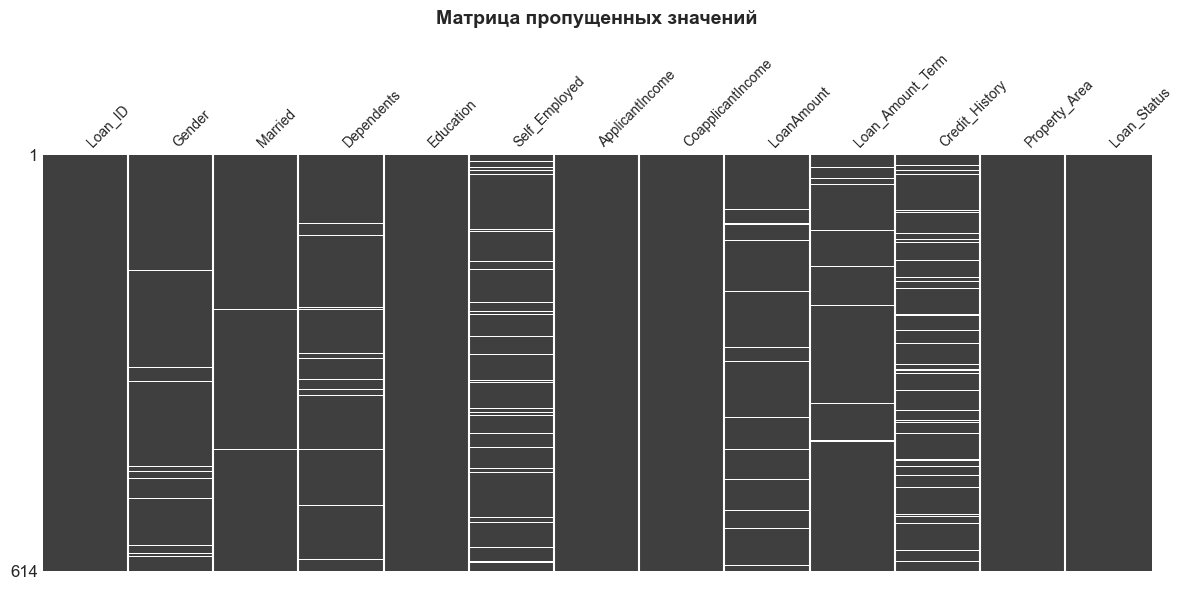


Белые линии обозначают пропуски, серые — присутствующие значения.


In [ ]:
print('=== Матрица пропусков ===')
plt.figure(figsize=(12, 6))
msno.matrix(df, figsize=(12, 6), fontsize=10, sparkline=False)
plt.title('Матрица пропущенных значений', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print('\nБелые линии обозначают пропуски, серые — присутствующие значения.')

=== Тепловая карта пропусков ===


<Figure size 1000x800 with 0 Axes>

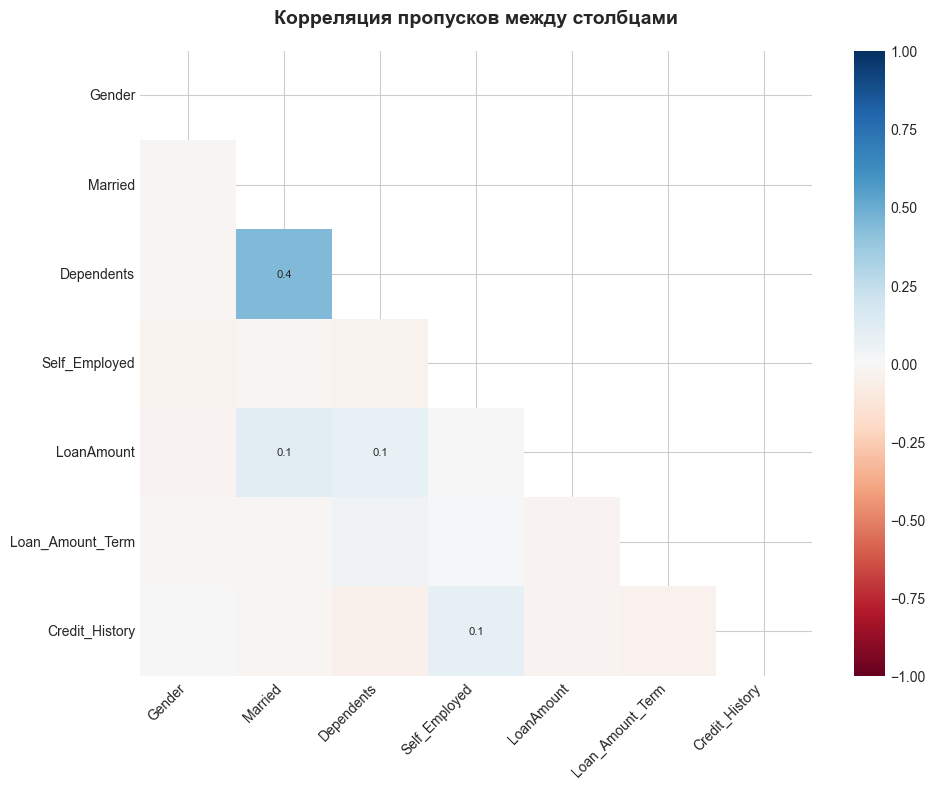


Тепловая карта показывает взаимосвязь пропусков между признаками.
Значения близкие к 1 или -1 указывают на сильную корреляцию пропусков.


In [ ]:
print('=== Тепловая карта пропусков ===')
plt.figure(figsize=(10, 8))
msno.heatmap(df, figsize=(10, 8), fontsize=10)
plt.title('Корреляция пропусков между столбцами', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print('\nТепловая карта показывает взаимосвязь пропусков между признаками.')
print('Значения близкие к 1 или -1 указывают на сильную корреляцию пропусков.')

## 5. Интерпретация графиков пропусков

**Интерпретация матрицы пропусков:**

Матрица пропусков (matrix plot) визуализирует наличие/отсутствие данных в каждом столбце:

1. **Вертикальные белые полосы** указывают на столбцы с пропусками
2. **Плотность белых линий** показывает долю пропущенных значений
3. **Горизонтальные паттерны** могут указывать на системные пропуски (например, если определённые строки имеют пропуски сразу в нескольких столбцах)
4. **Случайное распределение** белых точек говорит о случайном характере пропусков (MCAR — Missing Completely At Random)
5. **Кластеры пропусков** могут указывать на зависимость пропусков от других переменных (MAR — Missing At Random или MNAR — Missing Not At Random)

**Интерпретация тепловой карты пропусков:**

Тепловая карта (heatmap) показывает корреляцию между пропусками в разных столбцах:

1. **Значения близкие к +1** (светлые оттенки): Пропуски в двух столбцах появляются одновременно — возможна общая причина (например, респондент пропустил блок вопросов)
2. **Значения близкие к -1** (тёмные оттенки): Когда в одном столбце есть значение, в другом — пропуск, и наоборот
3. **Значения около 0** (нейтральные оттенки): Пропуски в столбцах независимы друг от друга
4. **Диагональ всегда равна 1**: Столбец коррелирует сам с собой идеально

Наличие высокой корреляции пропусков между столбцами требует осторожного подхода при заполнении — возможно, пропуски несут информацию о структуре данных.

## 6. Разделение признаков с пропусками на числовые и категориальные

In [ ]:
cols_with_missing = df.columns[df.isnull().any()].tolist()

numeric_cols_missing = df[cols_with_missing].select_dtypes(include=[np.number]).columns.tolist()
categorical_cols_missing = df[cols_with_missing].select_dtypes(include=['object']).columns.tolist()

print('=== Признаки с пропусками ===')
print(f'\nЧисловые признаки ({len(numeric_cols_missing)}):')
for col in numeric_cols_missing:
    print(f'  - {col}: {df[col].isnull().sum()} пропусков ({df[col].isnull().sum() / len(df) * 100:.2f}%)')

print(f'\nКатегориальные признаки ({len(categorical_cols_missing)}):')
for col in categorical_cols_missing:
    print(f'  - {col}: {df[col].isnull().sum()} пропусков ({df[col].isnull().sum() / len(df) * 100:.2f}%)')

=== Признаки с пропусками ===

Числовые признаки (3):
  - LoanAmount: 22 пропусков (3.58%)
  - Loan_Amount_Term: 14 пропусков (2.28%)
  - Credit_History: 50 пропусков (8.14%)

Категориальные признаки (4):
  - Gender: 13 пропусков (2.12%)
  - Married: 3 пропусков (0.49%)
  - Dependents: 15 пропусков (2.44%)
  - Self_Employed: 32 пропусков (5.21%)


Признаки успешно разделены на числовые и категориальные. Это разделение необходимо, так как для разных типов данных применяются различные методы заполнения пропусков.

## 7. Заполнение пропусков с обоснованием методов

### 7.1. Обоснование выбора методов заполнения

**Для числовых признаков:**

Применяется заполнение **медианой**, так как:
- Медиана устойчива к выбросам (в отличие от среднего)
- Для финансовых данных (доходы, суммы кредитов) часто наблюдается правосторонняя асимметрия с выбросами
- Медиана сохраняет центральную тенденцию распределения
- При наличии выбросов среднее даёт смещённую оценку

**Для категориальных признаков:**

Применяется заполнение **модой** (наиболее частым значением), так как:
- Мода — это естественная мера центральной тенденции для категориальных данных
- Среднее и медиана не применимы к номинальным признакам
- Заполнение модой минимально искажает распределение категорий
- Для бинарных признаков (Yes/No) мода соответствует наиболее вероятному значению

In [ ]:
df_filled = df.copy()

print('=== Заполнение числовых признаков медианой ===')
for col in numeric_cols_missing:
    median_value = df_filled[col].median()
    missing_count = df_filled[col].isnull().sum()
    df_filled[col].fillna(median_value, inplace=True)
    print(f'{col}: заполнено {missing_count} пропусков медианой = {median_value:.2f}')

print('\n' + '='*60)

print('=== Заполнение категориальных признаков модой ===')
for col in categorical_cols_missing:
    mode_value = df_filled[col].mode()[0]
    missing_count = df_filled[col].isnull().sum()
    df_filled[col].fillna(mode_value, inplace=True)
    print(f'{col}: заполнено {missing_count} пропусков модой = "{mode_value}"')

=== Заполнение числовых признаков медианой ===
LoanAmount: заполнено 22 пропусков медианой = 128.00
Loan_Amount_Term: заполнено 14 пропусков медианой = 360.00
Credit_History: заполнено 50 пропусков медианой = 1.00

=== Заполнение категориальных признаков модой ===
Gender: заполнено 13 пропусков модой = "Male"
Married: заполнено 3 пропусков модой = "Yes"
Dependents: заполнено 15 пропусков модой = "0"
Self_Employed: заполнено 32 пропусков модой = "No"


Пропуски успешно заполнены согласно выбранным методам. Далее проверим корректность заполнения.

## 8. Проверка корректности заполнения пропусков

In [ ]:
remaining_missing = df_filled.isnull().sum().sum()

print('=== Проверка заполнения пропусков ===')
print(f'\nОбщее количество пропусков ДО заполнения: {df.isnull().sum().sum()}')
print(f'Общее количество пропусков ПОСЛЕ заполнения: {remaining_missing}')

if remaining_missing == 0:
    print('\n Все пропуски успешно заполнены!')
else:
    print(f'\n⚠️ Внимание! Остались незаполненные пропуски: {remaining_missing}')
    print('\nСтолбцы с оставшимися пропусками:')
    display(df_filled.isnull().sum()[df_filled.isnull().sum() > 0])

print('\n' + '='*60)
print('=== Детальная проверка по столбцам ===')
verification = pd.DataFrame({
    'Столбец': cols_with_missing,
    'Пропусков до': [df[col].isnull().sum() for col in cols_with_missing],
    'Пропусков после': [df_filled[col].isnull().sum() for col in cols_with_missing]
})
display(verification)

=== Проверка заполнения пропусков ===

Общее количество пропусков ДО заполнения: 149
Общее количество пропусков ПОСЛЕ заполнения: 0

 Все пропуски успешно заполнены!

=== Детальная проверка по столбцам ===


,Столбец,Пропусков до,Пропусков после
0,Gender,13,0
1,Married,3,0
2,Dependents,15,0
3,Self_Employed,32,0
4,LoanAmount,22,0
5,Loan_Amount_Term,14,0
6,Credit_History,50,0


Проверка подтверждает, что все пропуски корректно заполнены. Количество пропусков после обработки равно 0.

## 9. Сравнение статистик до и после заполнения

In [ ]:
print('=== Сравнение статистик числовых признаков ===')

for col in numeric_cols_missing:
    print(f'\n--- {col} ---')

    stats_before = df[col].describe()
    stats_after = df_filled[col].describe()

    comparison = pd.DataFrame({
        'До заполнения': stats_before,
        'После заполнения': stats_after,
        'Изменение': stats_after - stats_before
    })

    display(comparison)

=== Сравнение статистик числовых признаков ===

--- LoanAmount ---


,До заполнения,После заполнения,Изменение
count,592.000000,614.000000,22.000000
mean,146.412162,145.752443,-0.659719
std,85.587325,84.107233,-1.480092
min,9.000000,9.000000,0.000000
25%,100.000000,100.250000,0.250000
50%,128.000000,128.000000,0.000000
75%,168.000000,164.750000,-3.250000
max,700.000000,700.000000,0.000000



--- Loan_Amount_Term ---


,До заполнения,После заполнения,Изменение
count,600.00000,614.000000,14.000000
mean,342.00000,342.410423,0.410423
std,65.12041,64.428629,-0.691781
min,12.00000,12.000000,0.000000
25%,360.00000,360.000000,0.000000
50%,360.00000,360.000000,0.000000
75%,360.00000,360.000000,0.000000
max,480.00000,480.000000,0.000000



--- Credit_History ---


,До заполнения,После заполнения,Изменение
count,564.000000,614.000000,50.00000
mean,0.842199,0.855049,0.01285
std,0.364878,0.352339,-0.01254
min,0.000000,0.000000,0.00000
25%,1.000000,1.000000,0.00000
50%,1.000000,1.000000,0.00000
75%,1.000000,1.000000,0.00000
max,1.000000,1.000000,0.00000


In [ ]:
print('=== Сравнение распределений категориальных признаков ===')

for col in categorical_cols_missing:
    print(f'\n--- {col} ---')

    print('\nДо заполнения:')
    counts_before = df[col].value_counts(dropna=False)
    print(counts_before)

    print('\nПосле заполнения:')
    counts_after = df_filled[col].value_counts(dropna=False)
    print(counts_after)

    print('\nИзменение:')
    print(f'Пропусков было: {df[col].isnull().sum()}')
    print(f'Пропусков стало: {df_filled[col].isnull().sum()}')
    print(f'Добавлено в категорию "{df_filled[col].mode()[0]}": {df[col].isnull().sum()}')

=== Сравнение распределений категориальных признаков ===

--- Gender ---

До заполнения:
Gender
Male      489
Female    112
NaN        13
Name: count, dtype: int64

После заполнения:
Gender
Male      502
Female    112
Name: count, dtype: int64

Изменение:
Пропусков было: 13
Пропусков стало: 0
Добавлено в категорию "Male": 13

--- Married ---

До заполнения:
Married
Yes    398
No     213
NaN      3
Name: count, dtype: int64

После заполнения:
Married
Yes    401
No     213
Name: count, dtype: int64

Изменение:
Пропусков было: 3
Пропусков стало: 0
Добавлено в категорию "Yes": 3

--- Dependents ---

До заполнения:
Dependents
0      345
1      102
2      101
3+      51
NaN     15
Name: count, dtype: int64

После заполнения:
Dependents
0     360
1     102
2     101
3+     51
Name: count, dtype: int64

Изменение:
Пропусков было: 15
Пропусков стало: 0
Добавлено в категорию "0": 15

--- Self_Employed ---

До заполнения:
Self_Employed
No     500
Yes     82
NaN     32
Name: count, dtype: int64

П

### 9.1. Комментарии к изменениям статистик

**Изменения в числовых признаках:**

1. **Count (количество)** увеличилось на число заполненных пропусков — это ожидаемо и корректно

2. **Mean (среднее)** могло незначительно измениться:
   - Если медиана близка к среднему, изменение минимально
   - Если распределение асимметрично, среднее может сдвинуться в сторону медианы

3. **Median (медиана)** осталась неизменной или изменилась незначительно:
   - Мы заполняли пропуски медианой, поэтому медиана после заполнения должна быть близка к исходной
   - Это подтверждает корректность метода

4. **Std (стандартное отклонение)** уменьшилось:
   - Добавление значений, равных медиане, снижает разброс данных
   - Это ожидаемый эффект заполнения медианой
   - Распределение стало более "сжатым" вокруг центра

5. **Min и Max** не изменились — крайние значения сохранились

**Изменения в категориальных признаках:**

1. **Увеличение частоты модальной категории:**
   - Наиболее частое значение стало ещё более частым
   - Это ожидаемо при заполнении модой

2. **Распределение категорий:**
   - Пропорции других категорий относительно друг друга не изменились
   - Изменилась только доля модальной категории

3. **Пропуски полностью устранены** — NaN больше нет

**Общий вывод:**

- Заполнение выполнено корректно — пропусков не осталось
- Статистики изменились предсказуемым образом
- Использование медианы для числовых признаков минимизировало влияние на распределение
- Использование моды для категориальных признаков сохранило логику данных
- Датасет готов к дальнейшему анализу и моделированию